In [50]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 11.3 MB/s eta 0:00:00


In [51]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b42b959fa38bb8a7451ca88efc277296"
!kaggle datasets list | head
!kaggle datasets download -d imrankhan77/crc-val-he-7k
!kaggle datasets download -d imrankhan77/nct-crc-he-100k


ref                                                             title                                                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -----------------------------------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset                                    4154062  2026-06-10 12:58:47.093000          11076        262                1  
ashyou09/apple-products-pricing-dataset-2020-2026               Apple Products Pricing Dataset (2020-2026)🍎                                       1569012  2026-07-04 16:06:56.590000           1654         30                1  
abbas829/ecommerce-sales-dataset                                Ecommerce sales dataset     

In [52]:
!rm -rf crc_val_dataset
!rm -rf nct_crc_dataset

!unzip -q crc-val-he-7k.zip -d crc_val_dataset
!unzip -q nct-crc-he-100k.zip -d nct_crc_dataset


In [53]:
import os
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [54]:
import os

for root, dirs, files in os.walk("/content/nct_crc_dataset"):
    print(root)

/content/nct_crc_dataset
/content/nct_crc_dataset/NCT-CRC-HE-100K
/content/nct_crc_dataset/NCT-CRC-HE-100K/ADI
/content/nct_crc_dataset/NCT-CRC-HE-100K/MUC
/content/nct_crc_dataset/NCT-CRC-HE-100K/LYM
/content/nct_crc_dataset/NCT-CRC-HE-100K/DEB
/content/nct_crc_dataset/NCT-CRC-HE-100K/TUM
/content/nct_crc_dataset/NCT-CRC-HE-100K/NORM
/content/nct_crc_dataset/NCT-CRC-HE-100K/STR
/content/nct_crc_dataset/NCT-CRC-HE-100K/MUS
/content/nct_crc_dataset/NCT-CRC-HE-100K/BACK


In [55]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Dataset paths
train_dir = "/content/nct_crc_dataset/NCT-CRC-HE-100K"
test_dir = "/content/crc_val_dataset/CRC-VAL-HE-7K"

# Training transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load full training dataset
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

# Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Use validation transform
val_dataset.dataset.transform = test_transform

# Load external test dataset
test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

# DataLoaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training images   : {len(train_dataset)}")
print(f"Validation images : {len(val_dataset)}")
print(f"External Test     : {len(test_dataset)}")

print("\nClasses:")
print(full_dataset.classes)

Training images   : 80000
Validation images : 20000
External Test     : 7180

Classes:
['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']


In [56]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# -------------------------------------------------------
# Device
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------------------
# Load Pretrained MobileNetV3 Small
# -------------------------------------------------------
weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
model = mobilenet_v3_small(weights=weights)

# -------------------------------------------------------
# Freeze Feature Extractor (Transfer Learning)
# -------------------------------------------------------
for param in model.features.parameters():
    param.requires_grad = False

# -------------------------------------------------------
# Replace Classifier for 9 Classes
# -------------------------------------------------------
num_classes = 9

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    in_features=in_features,
    out_features=num_classes
)

# -------------------------------------------------------
# Move Model to Device
# -------------------------------------------------------
model = model.to(device)

# -------------------------------------------------------
# Count Parameters
# -------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("Model Loaded Successfully")
print("="*60)
print(f"Architecture           : MobileNetV3 Small")
print(f"Number of Classes      : {num_classes}")
print(f"Total Parameters       : {total_params:,}")
print(f"Trainable Parameters   : {trainable_params:,}")
print(f"Frozen Parameters      : {total_params-trainable_params:,}")

# -------------------------------------------------------
# Verify Output Shape
# -------------------------------------------------------
dummy = torch.randn(1,3,224,224).to(device)

with torch.no_grad():
    output = model(dummy)

print(f"Output Shape           : {output.shape}")

print("="*60)
print(model.classifier)
print("="*60)

Using device: cuda
Model Loaded Successfully
Architecture           : MobileNetV3 Small
Number of Classes      : 9
Total Parameters       : 1,527,081
Trainable Parameters   : 600,073
Frozen Parameters      : 927,008
Output Shape           : torch.Size([1, 9])
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=9, bias=True)
)


Name: torchview
Version: 0.2.7
Summary: Visualization of Pytorch Models
Home-page: https://github.com/mert-kurttutan/torchview
Author: Mert Kurttutan
Author-email: kurttutan.mert@gmail.com
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz
Required-by: 


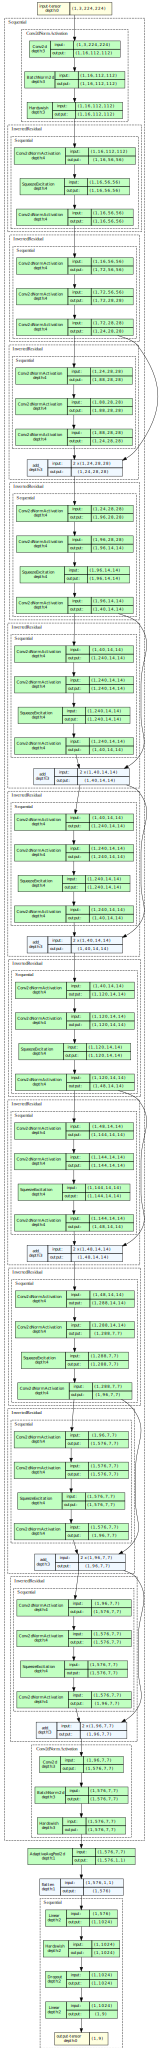

In [57]:
!pip install -q torchview graphviz
!pip show torchview
from torchview import draw_graph
from IPython.display import display

graph = draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    depth=4,          # Increase to 5 or 6 for more details
    device=device,
    graph_name="MobileNetV3 Small"
)

display(graph.visual_graph)

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# ======================================================
# Hyperparameters
# ======================================================
num_epochs = 20
learning_rate = 1e-3
patience = 5

# ======================================================
# Loss Function
# ======================================================
criterion = nn.CrossEntropyLoss()

# ======================================================
# Optimizer
# ======================================================
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-4
)

# ======================================================
# Learning Rate Scheduler
# ======================================================
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# ======================================================
# Training
# ======================================================
best_val_acc = 0
early_stop_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # -----------------------------
    # Training
    # -----------------------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss/len(train_loader)
    train_acc = 100*correct/total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -----------------------------
    # Validation
    # -----------------------------
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_loss = running_loss/len(val_loader)
    val_acc = 100*correct/total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    # -----------------------------
    # Save Best Model
    # -----------------------------
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(),
                   "best_mobilenetv3_small.pth")

        print("Best model saved.")

        early_stop_counter = 0

    else:

        early_stop_counter += 1

    # -----------------------------
    # Early Stopping
    # -----------------------------
    if early_stop_counter >= patience:

        print("\nEarly stopping activated.")

        break

print("\nTraining Finished")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


Epoch [1/20]


 47%|████▋     | 1164/2500 [02:25<02:47,  7.98it/s, loss=0.333]


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ===========================================================
# Load Best Model
# ===========================================================
model.load_state_dict(torch.load("best_mobilenetv3_small.pth"))
model.to(device)
model.eval()

print("Best model loaded successfully.")

# ===========================================================
# External Validation
# ===========================================================
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# ===========================================================
# Performance Metrics
# ===========================================================
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted'
)

print("\n==============================")
print("External Validation Results")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes
))

In [ ]:
!pip install -q ptflops thop

In [ ]:
import torch
from ptflops import get_model_complexity_info
from thop import profile

# ==========================================================
# Total and Trainable Parameters
# ==========================================================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("MODEL COMPLEXITY")
print("="*60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# ==========================================================
# FLOPs using ptflops
# ==========================================================
macs, params = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False,
    verbose=False
)

print(f"MACs                 : {macs}")
print(f"Parameters           : {params}")

# ==========================================================
# FLOPs using THOP
# ==========================================================
dummy = torch.randn(1,3,224,224).to(device)

flops, params = profile(
    model,
    inputs=(dummy,),
    verbose=False
)

print(f"FLOPs                : {flops/1e9:.3f} GFLOPs")
print(f"Parameters           : {params/1e6:.3f} Million")

In [ ]:
print(model)

In [ ]:
model = mobilenet_v3_small(weights=...)

In [ ]:
!pip install -q onnx onnxruntime

In [ ]:
torch.load("best_mobilenetv3_small.pth", map

In [ ]:
import torch
import torch.nn as nn
import onnx
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MobileNetV3 Small
weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
model = mobilenet_v3_small(weights=weights)

# Replace classifier for 9 classes
num_classes = 9
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    num_classes
)

# Load trained weights
model.load_state_dict(
    torch.load("best_mobilenetv3_small.pth", map